<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Week_4.13_Refinement_of_FinalProject_RyanNguyen_SpecialTopics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
import numpy as np
import shap
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import multilabel_confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense





In [2]:

# Download latest version
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)

100%|██████████| 7.90M/7.90M [00:01<00:00, 6.26MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1


In [3]:


# Show files downloaded
print("Files in dataset folder:")
print(os.listdir(path))

# Build full CSV path
csv_path = os.path.join(path, "spotify-tracks-dataset-detailed.csv")
print("CSV path:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# Basic shape
print("Dataset shape:", df.shape)

# First few rows
df.head()

Files in dataset folder:
['spotify-tracks-dataset-detailed.csv']
CSV path: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1/spotify-tracks-dataset-detailed.csv
Dataset shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# --- REFINED DATA PREPARATION (DEEP LEARNING APPROACH) ---
# 1. Fresh copy
data = df.copy().dropna()

# 2. Genre Family Mapping
genre_mapping = {
    'acoustic': 'Acoustic/Folk', 'folk': 'Acoustic/Folk', 'bluegrass': 'Acoustic/Folk',
    'blues': 'Blues/Jazz', 'jazz': 'Blues/Jazz', 'soul': 'Blues/Jazz',
    'dance': 'Electronic', 'edm': 'Electronic', 'techno': 'Electronic', 'house': 'Electronic',
    'alt-rock': 'Rock', 'hard-rock': 'Rock', 'punk': 'Rock', 'metal': 'Rock', 'heavy-metal': 'Rock',
    'hip-hop': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap',
    'classical': 'Classical', 'opera': 'Classical',
    'pop': 'Pop', 'indie-pop': 'Pop', 'k-pop': 'Pop'
}
data['genre_family'] = data['track_genre'].map(genre_mapping).fillna('Other/Indie')

# 3. Define X (Raw Features Only)
feature_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = data[feature_cols]

# 4. Define y (Multi-Label Binarizer)
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(data['genre_family'].apply(lambda x: [x]))

# 5. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X and y defined successfully! Prepared {X_train_scaled.shape[0]} songs.")

X and y defined successfully! Prepared 91199 songs.


In [5]:
# Column names
print(df.columns.tolist())

# Missing values
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))

# Data types
print("\nData types:")
print(df.dtypes)

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values by column:
artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Data types:
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              f

In [6]:
# --- REFINED DEEP LEARNING MODEL (Multi-Label Version) ---
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),
    # Use sigmoid for the final layer to allow multiple genre labels
    layers.Dense(y_train.shape[1], activation="sigmoid")
])

model.compile(
    optimizer="adam",
    # Switching to binary_crossentropy fixes the ValueError!
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    verbose=1
)

Epoch 1/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8146 - loss: 0.1567 - val_accuracy: 0.8149 - val_loss: 0.1434
Epoch 2/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8172 - loss: 0.1446 - val_accuracy: 0.8155 - val_loss: 0.1430
Epoch 3/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8178 - loss: 0.1428 - val_accuracy: 0.8151 - val_loss: 0.1408
Epoch 4/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8177 - loss: 0.1414 - val_accuracy: 0.8155 - val_loss: 0.1402
Epoch 5/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8180 - loss: 0.1404 - val_accuracy: 0.8152 - val_loss: 0.1397
Epoch 6/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8183 - loss: 0.1396 - val_accuracy: 0.8159 - val_loss: 0.1394
Epoch 7/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8181 - loss: 0.1390 - val_accuracy: 0.8154 - val_loss: 0.1396
Epoch 8/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8185 - loss: 0.1383 - val_accuracy: 0.

In [7]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.13555815815925598
Test MAE: 0.8190789222717285


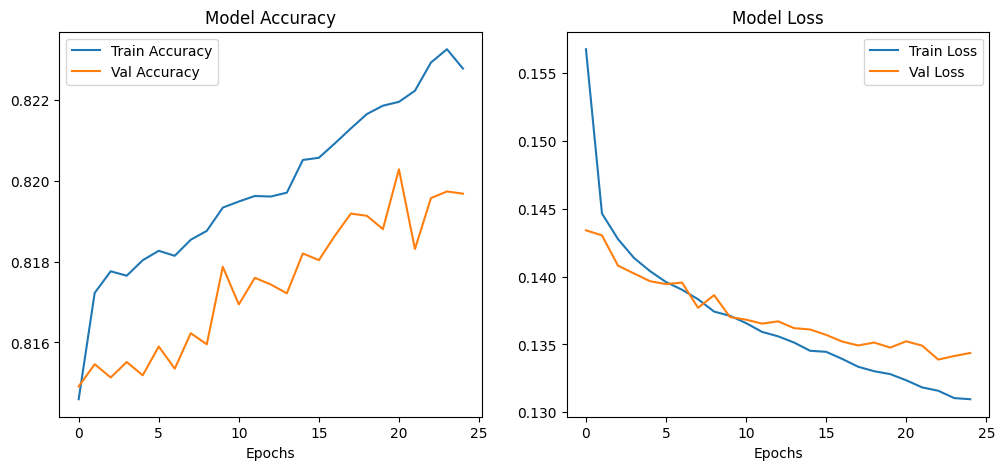

In [8]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [9]:
def get_genre_dna(test_index):
    # 1. Get the actual labels (using mlb instead of le)
    # y_test[test_index] is now a row of 0s and 1s
    actual_labels = mlb.inverse_transform(y_test[test_index:test_index+1])[0]

    # 2. Predict probabilities
    probs = model.predict(X_test_scaled[test_index:test_index+1])[0]

    # 3. Get the top 3 matches
    top_indices = np.argsort(probs)[-3:][::-1]
    top_genres = mlb.classes_[top_indices]
    top_probs = probs[top_indices]

    print(f"--- Music DNA for Test Song #{test_index} ---")
    print(f"Actual Label: {', '.join(actual_labels)}")
    print("\nModel's Top 3 Predictions:")
    for genre, p in zip(top_genres, top_probs):
        print(f"🧬 {genre}: {p*100:.2f}%")

# Try it out!
get_genre_dna(42)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
--- Music DNA for Test Song #42 ---
Actual Label: Blues/Jazz

Model's Top 3 Predictions:
🧬 Other/Indie: 96.80%
🧬 Electronic: 1.08%
🧬 Rock: 0.19%


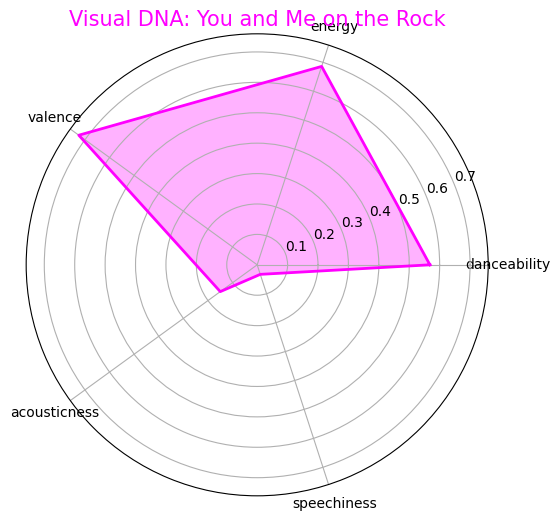

In [10]:

def plot_visual_dna(test_index):
    # The 'Nucleotides' of your Music DNA
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    values = data.iloc[test_index][features].values
    song_name = data.iloc[test_index]['track_name']

    # Create the Radar Chart
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='magenta', alpha=0.3)
    ax.plot(angles, values, color='magenta', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)

    plt.title(f"Visual DNA: {song_name}", size=15, color='magenta')
    plt.show()

# Run it for the same song you tested earlier
plot_visual_dna(42)

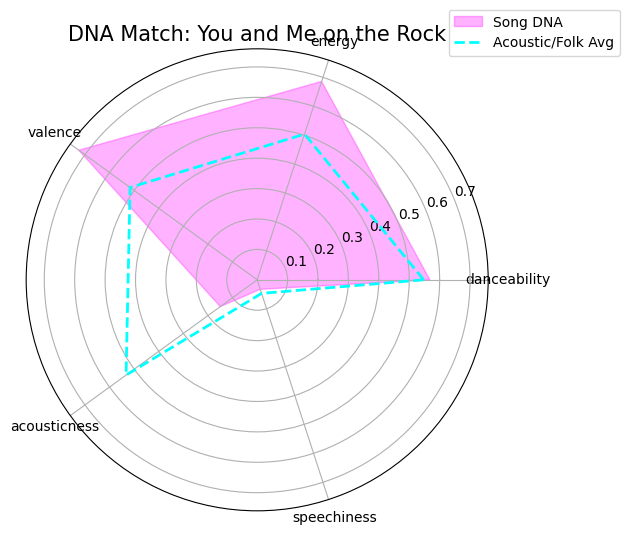

In [11]:
def plot_dna_comparison(test_index):
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    song_data = data.iloc[test_index]
    actual_family = song_data['genre_family']

    # Get the average DNA for this entire Genre Family
    family_avg = data[data['genre_family'] == actual_family][features].mean().values
    song_values = song_data[features].values

    # Setup plot
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Plot Song DNA
    ax.fill(angles, np.concatenate((song_values, [song_values[0]])), color='magenta', alpha=0.3, label="Song DNA")
    # Plot Genre Average DNA
    ax.plot(angles, np.concatenate((family_avg, [family_avg[0]])), color='cyan', linestyle='--', linewidth=2, label=f"{actual_family} Avg")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(f"DNA Match: {song_data['track_name']}", size=15)
    plt.show()

plot_dna_comparison(42)

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


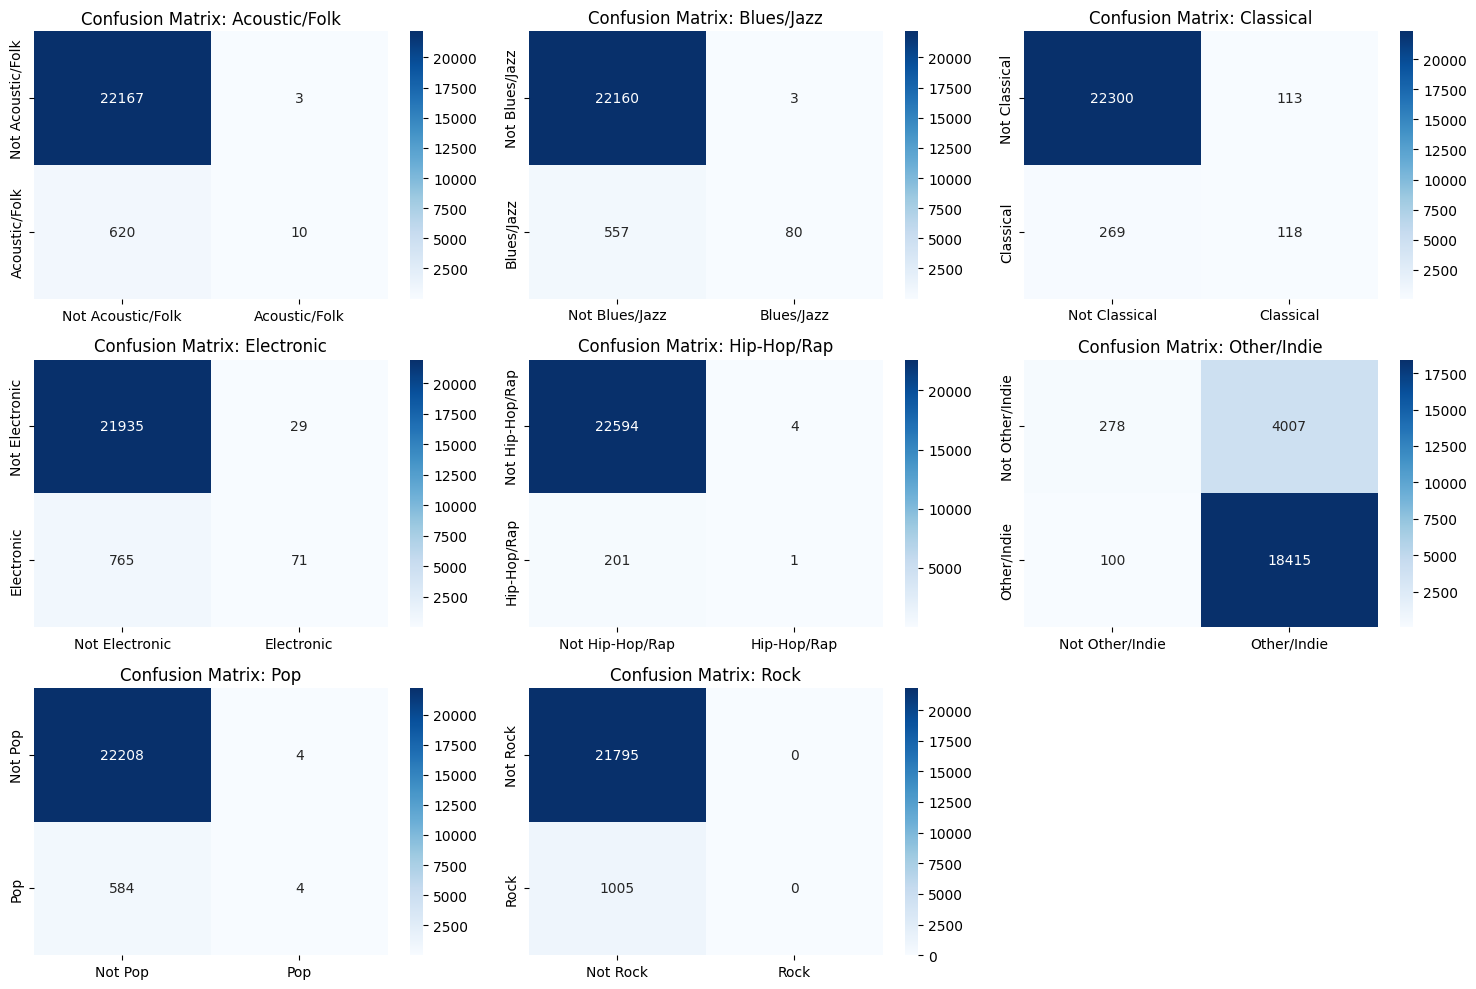

               precision    recall  f1-score   support

Acoustic/Folk       0.77      0.02      0.03       630
   Blues/Jazz       0.96      0.13      0.22       637
    Classical       0.51      0.30      0.38       387
   Electronic       0.71      0.08      0.15       836
  Hip-Hop/Rap       0.20      0.00      0.01       202
  Other/Indie       0.82      0.99      0.90     18515
          Pop       0.50      0.01      0.01       588
         Rock       0.00      0.00      0.00      1005

    micro avg       0.82      0.82      0.82     22800
    macro avg       0.56      0.19      0.21     22800
 weighted avg       0.76      0.82      0.75     22800
  samples avg       0.82      0.82      0.82     22800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# 1. Get predictions (probabilities)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convert probabilities to hard 0s and 1s (using 0.5 threshold)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Generate the matrices
matrices = multilabel_confusion_matrix(y_test, y_pred)

# 4. Plot a few key genres to see the "hits" and "misses"
plt.figure(figsize=(15, 10))
for i, genre in enumerate(mlb.classes_):
    plt.subplot(3, 3, i+1)
    sns.heatmap(matrices[i], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not ' + genre, genre],
                yticklabels=['Not ' + genre, genre])
    plt.title(f'Confusion Matrix: {genre}')

plt.tight_layout()
plt.show()

# 5. Print the full text report for precision/recall
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

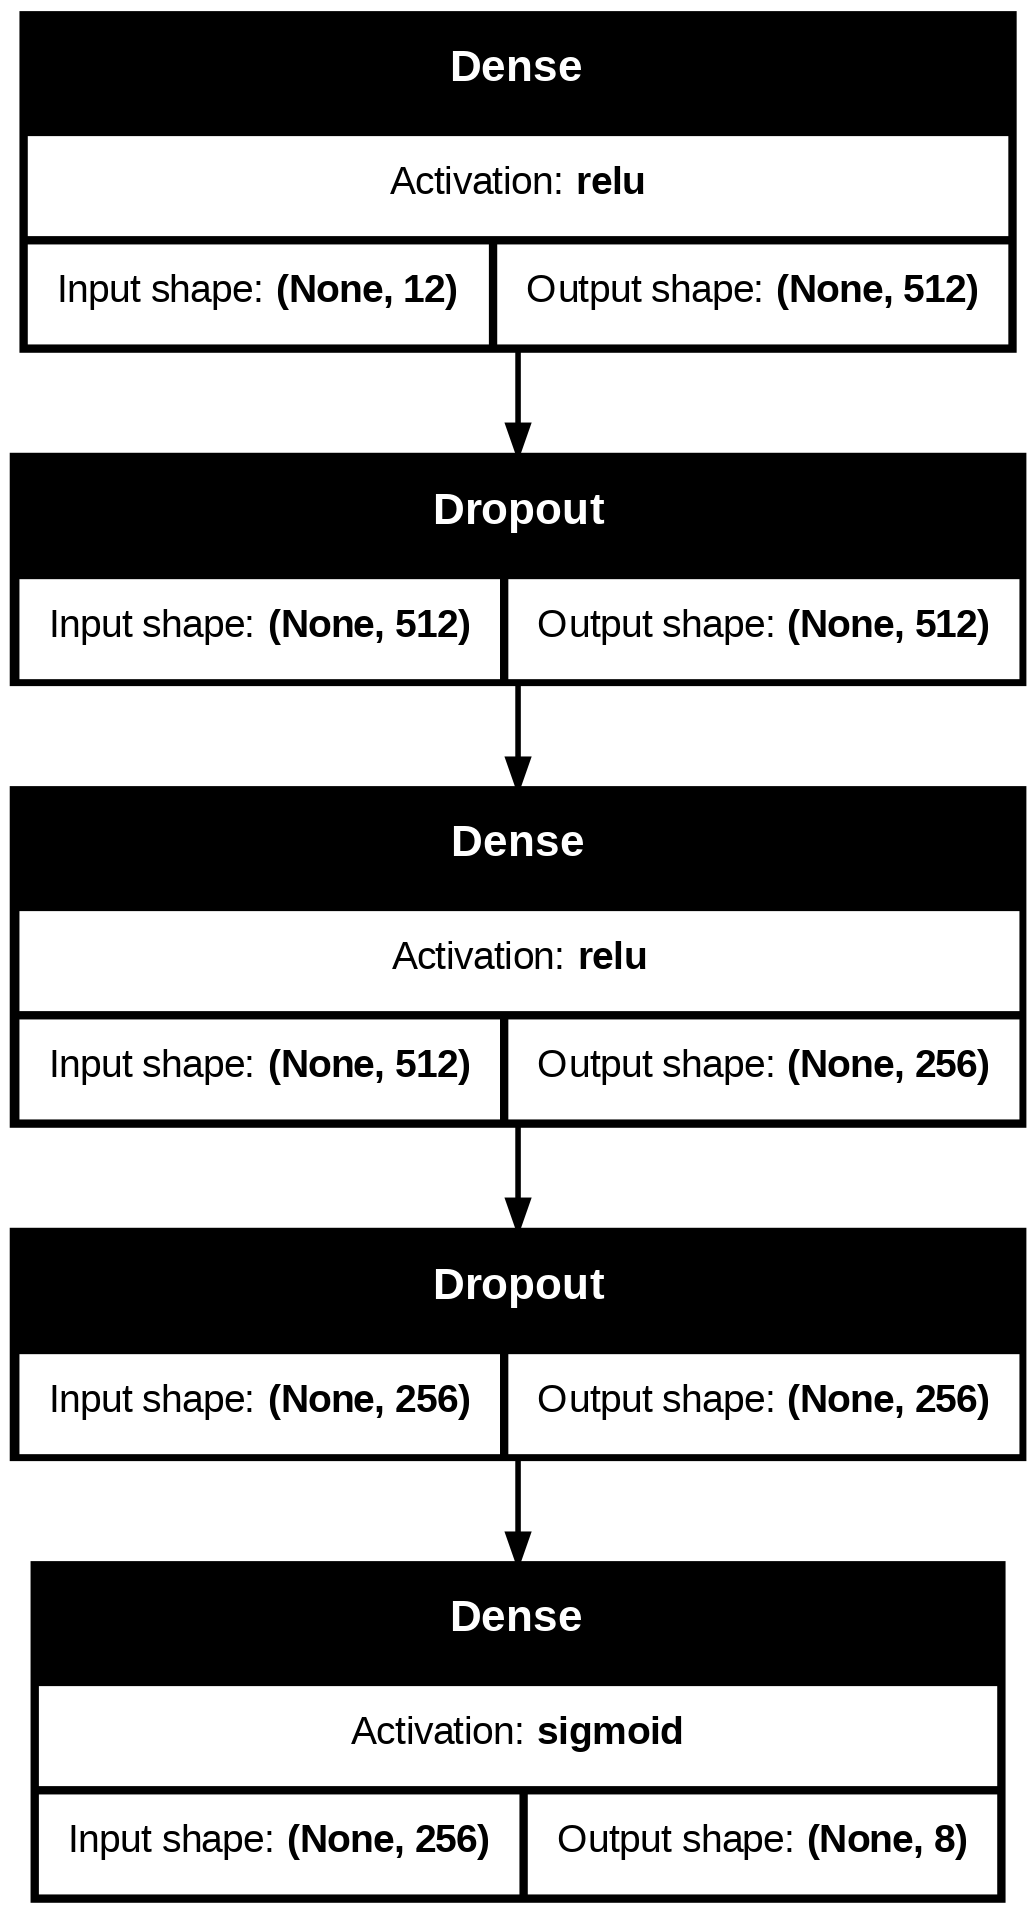

In [ ]:

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_activations=True)

In [13]:
# Create a balanced subset for visualization ONLY
# This prevents 'Other/Indie' from crowding the latent space
sample_per_genre = 500
df_balanced = data.groupby('genre_family').apply(lambda x: x.sample(n=min(len(x), sample_per_genre))).reset_index(drop=True)

# Update your X_visual and y_visual variables
X_visual = scaler.transform(df_balanced[feature_cols])
y_visual_labels = df_balanced['genre_family']

print(f"Balanced visualization dataset created with {len(df_balanced)} samples.")

Balanced visualization dataset created with 4000 samples.


/tmp/ipykernel_9630/833376889.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = data.groupby('genre_family').apply(lambda x: x.sample(n=min(len(x), sample_per_genre))).reset_index(drop=True)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


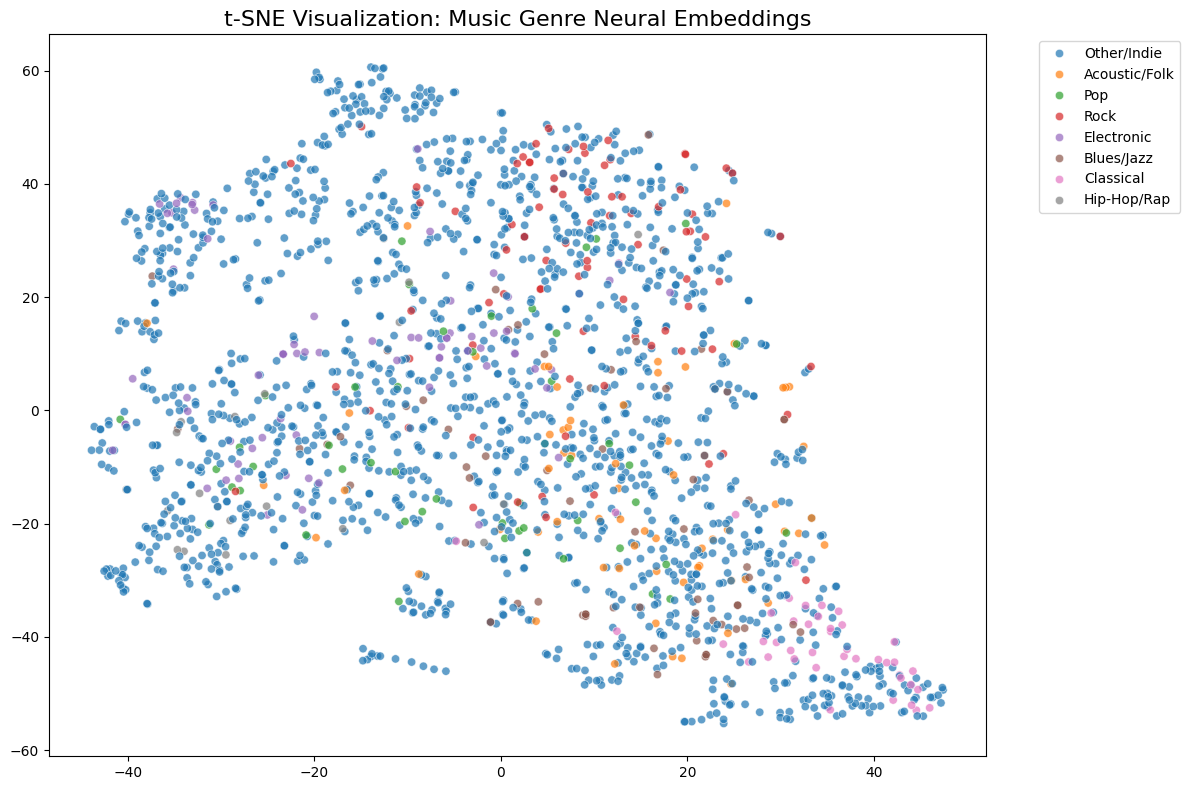

In [14]:
# 1. Access the input directly from the first layer to avoid the AttributeError
# 2. Extract the 256-node hidden layer (which is index 3 in your architecture)
latent_model = Model(inputs=model.layers[0].input, outputs=model.layers[3].output)
# Get embeddings for a sample of the test data (t-SNE is slow on all 22,000 rows)
sample_size = 2000
X_sample = X_test_scaled[:sample_size]
y_sample_labels = mlb.inverse_transform(y_test[:sample_size])

# Grab the primary genre for coloring purposes
primary_labels = [labels[0] if len(labels) > 0 else 'Other/Indie' for labels in y_sample_labels]
latent_features = latent_model.predict(X_sample)

# Run t-SNE to squash 256 dimensions down to 2
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(latent_features)

# Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=primary_labels, palette='tab10', alpha=0.7)
plt.title('t-SNE Visualization: Music Genre Neural Embeddings', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

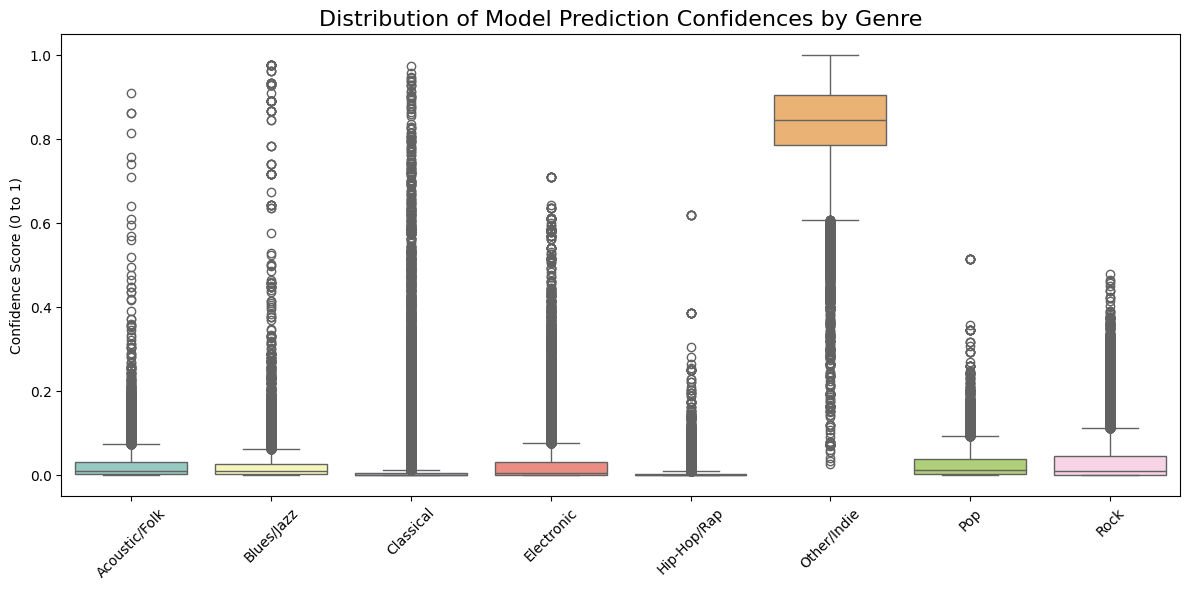

In [15]:
# --- 2. BOX PLOT OF CONFIDENCE SCORES ---
# Convert predictions back to a dataframe for plotting
probs_df = pd.DataFrame(y_pred_probs, columns=mlb.classes_)

plt.figure(figsize=(12, 6))
sns.boxplot(data=probs_df, palette="Set3")
plt.title("Distribution of Model Prediction Confidences by Genre", fontsize=16)
plt.ylabel("Confidence Score (0 to 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 12))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 12))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 12))']
  warnings.warn(msg

SHAP Summary for: Acoustic/Folk


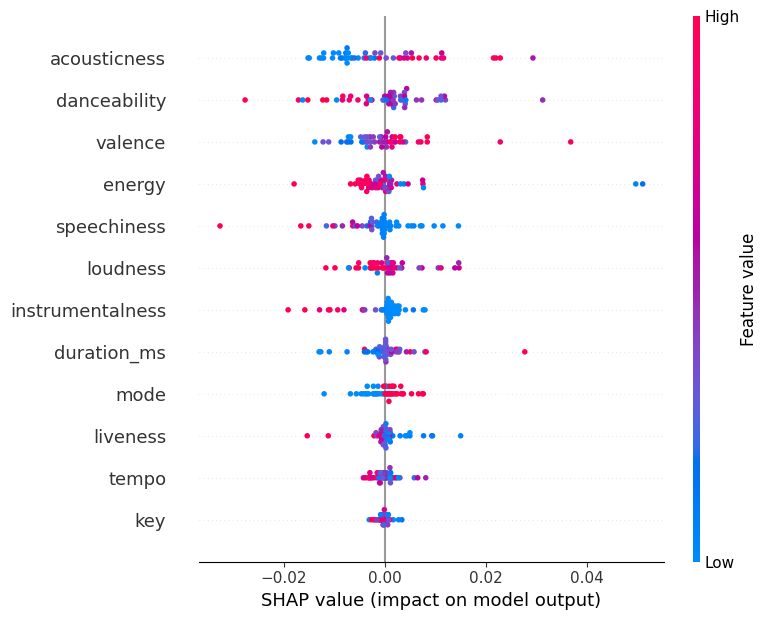

In [16]:
# --- 3. AUTO-DETECT SHAP VISUALIZATION ---
# 1. Use the current model and a small background sample
background = X_train_scaled[:100]
explainer = shap.DeepExplainer(model, background)

# 2. Calculate SHAP values for 50 songs
test_sample = X_test_scaled[:50]
shap_values = explainer.shap_values(test_sample)

# 3. Handle multi-output format based on the returned shape
genre_index = 0
current_feature_names = feature_cols

print(f"SHAP Summary for: {mlb.classes_[genre_index]}")

# FIX: Check if SHAP returned a list or a 3D array
if isinstance(shap_values, list):
    # Older SHAP versions return a list of length 'num_classes'
    shap_values_to_plot = shap_values[genre_index]
else:
    # Newer SHAP versions return a 3D array: (samples, features, classes)
    shap_values_to_plot = shap_values[:, :, genre_index]

# 4. Plot
shap.summary_plot(
    shap_values_to_plot,
    test_sample,
    feature_names=current_feature_names
)

In [17]:
# --- NEW: UNSUPERVISED AUTOENCODER ---
input_dim = X_train_scaled.shape[1] # 12 features

# Encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation='relu')(input_layer)
bottleneck = layers.Dense(4, activation='relu', name="bottleneck")(encoded) # 4D Latent Space

# Decoder
decoded = layers.Dense(8, activation='relu')(bottleneck)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train it to reconstruct itself (X to X)
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=128, verbose=0)

# Extract just the encoder part for visualization
encoder_model = Model(inputs=input_layer, outputs=bottleneck)
unsupervised_embeddings = encoder_model.predict(X_visual) # Use the balanced data from Step 1

print("Unsupervised Autoencoder trained and bottleneck features extracted.")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step
Unsupervised Autoencoder trained and bottleneck features extracted.


In [18]:
# Calculate class weights manually to handle the imbalance
total_samples = len(y_train)
class_weights = {}

for i, class_name in enumerate(mlb.classes_):
    class_count = np.sum(y_train[:, i])
    # The standard formula for balancing weights
    weight = total_samples / (len(mlb.classes_) * class_count)
    class_weights[i] = weight

# Train the model with the weights
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    class_weight=class_weights, # <--- ADD THIS HERE
    verbose=1
)

Epoch 1/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2748 - loss: 0.2587 - val_accuracy: 0.2776 - val_loss: 0.3171
Epoch 2/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2592 - loss: 0.2469 - val_accuracy: 0.2753 - val_loss: 0.3217
Epoch 3/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2594 - loss: 0.2441 - val_accuracy: 0.2412 - val_loss: 0.3374
Epoch 4/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2546 - loss: 0.2412 - val_accuracy: 0.2510 - val_loss: 0.3267
Epoch 5/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2585 - loss: 0.2390 - val_accuracy: 0.2488 - val_loss: 0.3341
Epoch 6/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2601 - loss: 0.2372 - val_accuracy: 0.2526 - val_loss: 0.3292
Epoch 7/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2604 - loss: 0.2357 - val_accuracy: 0.2595 - val_loss: 0.3251
Epoch 8/25
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2576 - loss: 0.2344 - val_accuracy: 0.

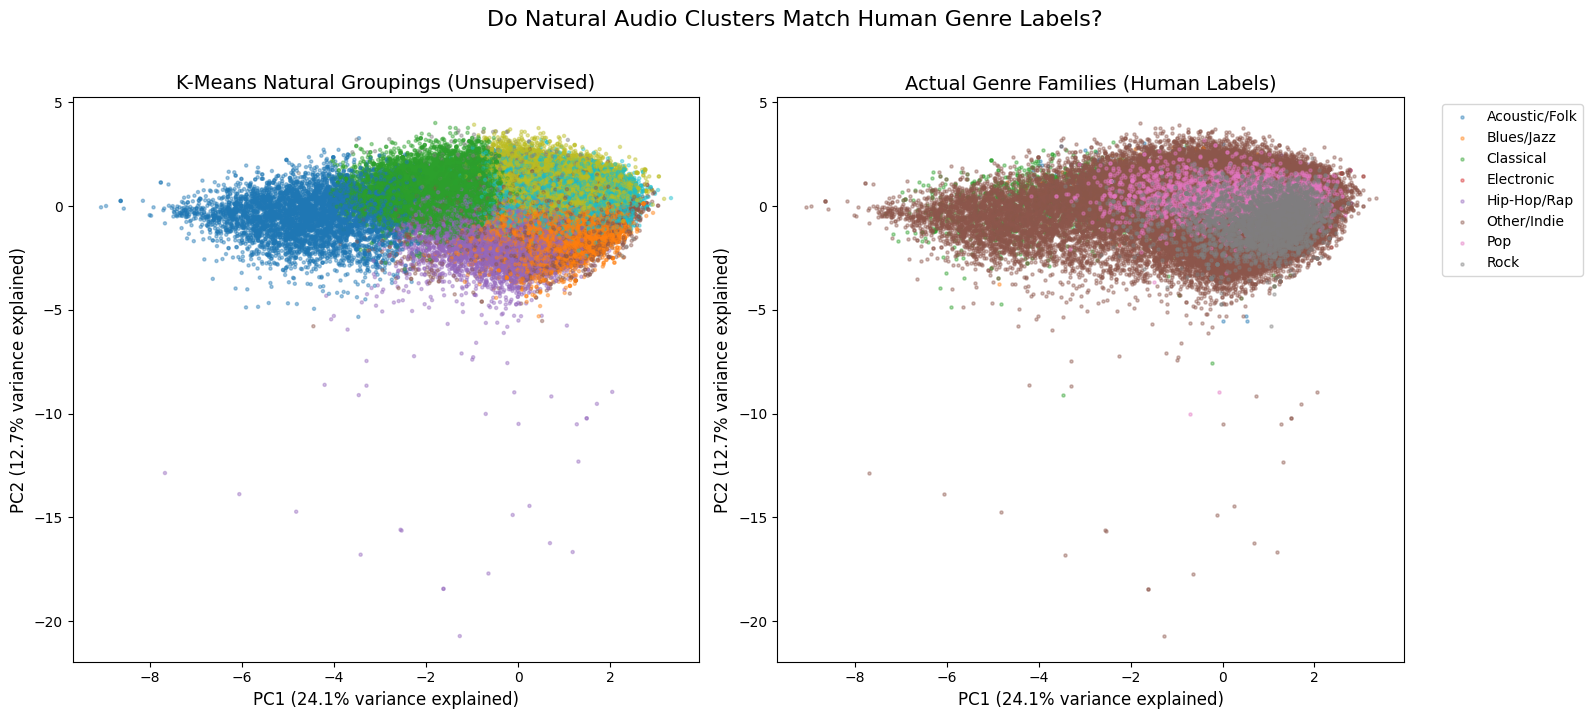

In [22]:
# --- FIXED: K-MEANS + PCA PLOT WITH PROPER AXIS LABELS ---
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
var_explained = pca.explained_variance_ratio_

primary_labels = [mlb.classes_[np.argmax(row)] if np.sum(row) > 0 else 'Other/Indie' for row in y_train]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.4, s=5)
axes[0].set_title('K-Means Natural Groupings (Unsupervised)', fontsize=14)
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=12)

palette = sns.color_palette('tab10', n_colors=len(mlb.classes_))
for i, genre in enumerate(mlb.classes_):
    mask = [l == genre for l in primary_labels]
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=genre, alpha=0.4, s=5, color=palette[i])
axes[1].set_title('Actual Genre Families (Human Labels)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Do Natural Audio Clusters Match Human Genre Labels?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

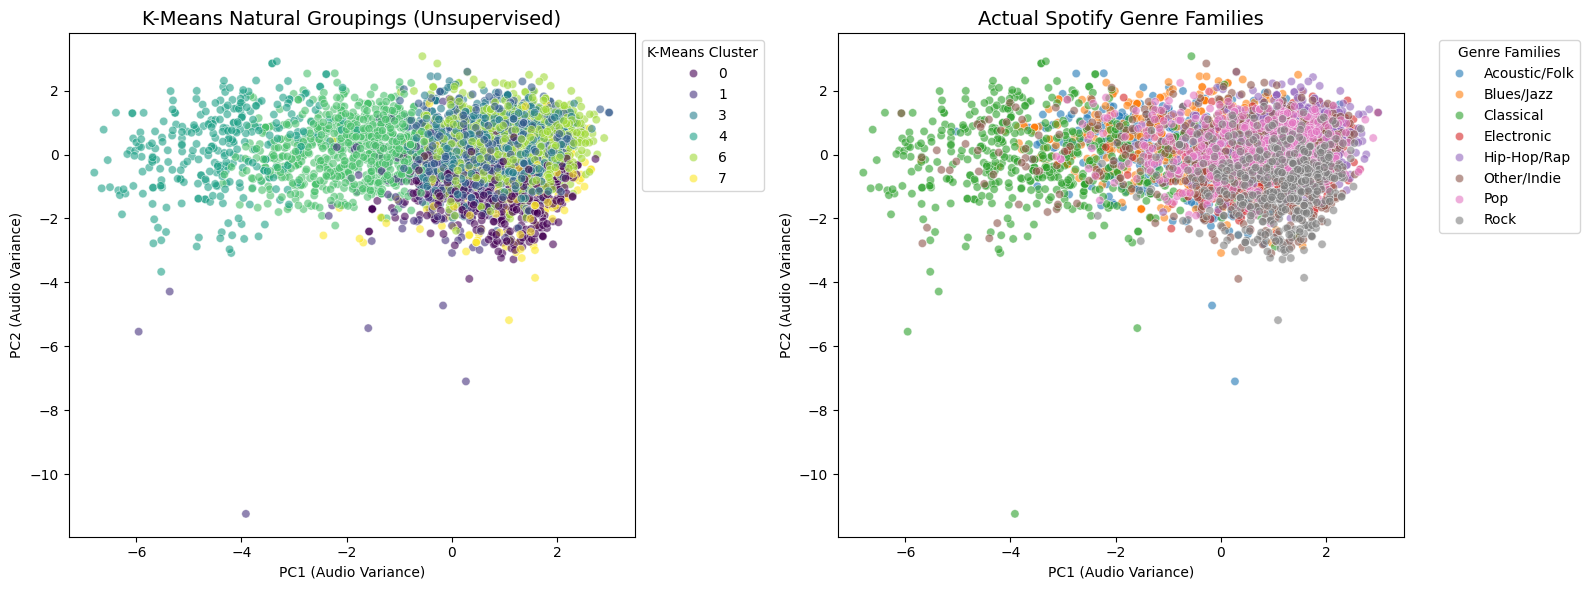

In [23]:
# --- IMPROVED VISUALIZATION: NATURAL VS ACTUAL CLUSTERS ---
pca = PCA(n_components=2)
# Using the balanced data from your earlier Step 1 to prevent 'Indie' dominance
X_pca = pca.fit_transform(X_visual)

plt.figure(figsize=(16, 6))

# Subplot 1: Unsupervised (K-Means)
plt.subplot(1, 2, 1)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_visual)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.6)
plt.title('K-Means Natural Groupings (Unsupervised)', fontsize=14)
plt.xlabel('PC1 (Audio Variance)')
plt.ylabel('PC2 (Audio Variance)')
plt.legend(title="K-Means Cluster", bbox_to_anchor=(1.0, 1), loc='upper left')

# Subplot 2: Actual Genres
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_visual_labels, palette='tab10', alpha=0.6)
plt.title('Actual Spotify Genre Families', fontsize=14)
plt.xlabel('PC1 (Audio Variance)')
plt.ylabel('PC2 (Audio Variance)')
# The legend is moved outside to the right to prevent overlap
plt.legend(title="Genre Families", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # This prevents the two subplots from squishing together
plt.show()

In [21]:


# Prepare data for Sankey: Count flows from original genre to family
sankey_data = data.groupby(['track_genre', 'genre_family']).size().reset_index(name='count')

# Create labels (unique list of all original genres + families)
all_nodes = list(sankey_data['track_genre'].unique()) + list(sankey_data['genre_family'].unique())
node_map = {name: i for i, name in enumerate(all_nodes)}

fig = go.Figure(data=[go.Sankey(
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = all_nodes),
    link = dict(
        source = sankey_data['track_genre'].map(node_map),
        target = sankey_data['genre_family'].map(node_map),
        value = sankey_data['count']
    ))])

fig.update_layout(title_text="Genre Mapping Transparency: 114 Sub-genres to 8 Families", font_size=10)
fig.show()

## Unsupervised Autoencoder

Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5087 - val_loss: 0.3393
Epoch 2/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3127 - val_loss: 0.2974
Epoch 3/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2785 - val_loss: 0.2679
Epoch 4/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2550 - val_loss: 0.2489
Epoch 5/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2409 - val_loss: 0.2393
Epoch 6/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2309 - val_loss: 0.2278
Epoch 7/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2230 - val_loss: 0.2215
Epoch 8/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2162 - val_loss: 0.2157
Epoch 9/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2103 - val_loss: 0.2109
Epoch 10/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2050 - val_loss: 0.2049
Epoch 11/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2005 - val_loss: 0.2006
Epoch 12/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

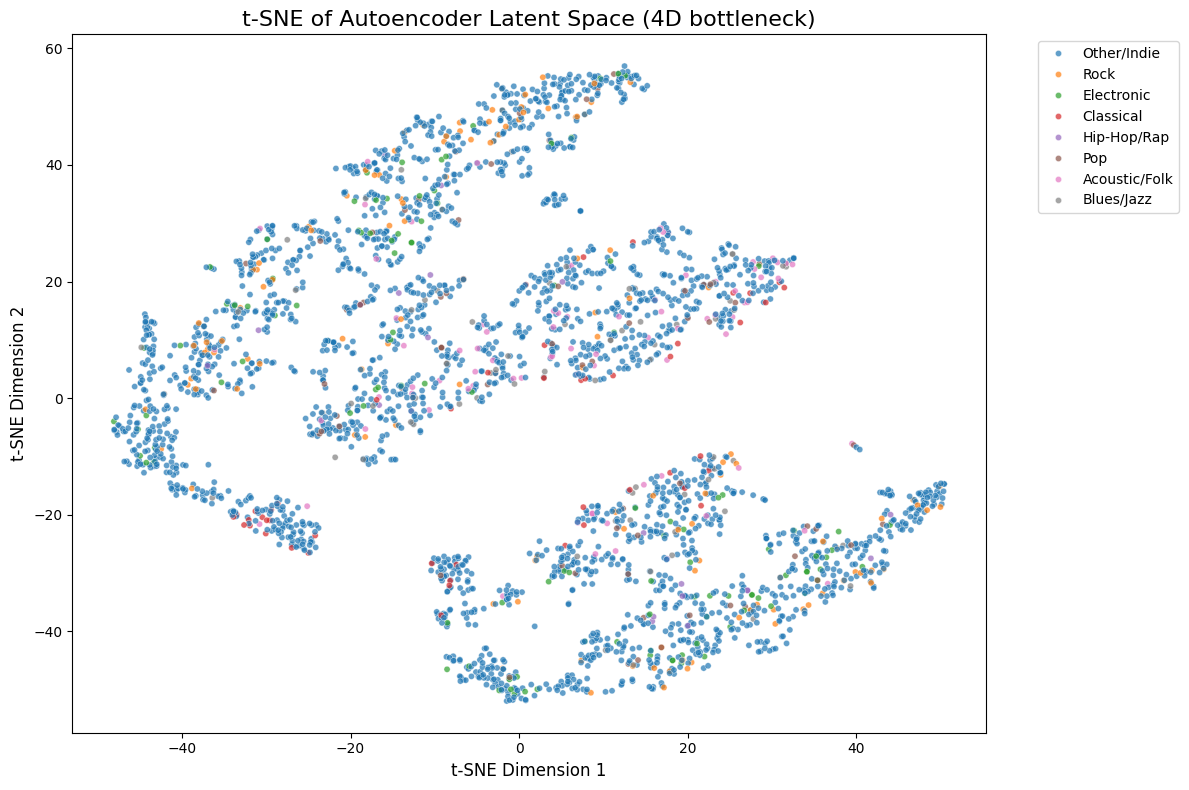

In [26]:
input_dim = X_train_scaled.shape[1]  # 12 features
encoding_dim = 4  # bottleneck

# Build symmetric autoencoder
inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(encoding_dim, activation='relu', name='bottleneck')(encoded)  # 4D latent space
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, bottleneck)  # encoder-only model for later

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=30, batch_size=256,
                validation_split=0.1, verbose=1)

# Get latent representations
latent_train = encoder.predict(X_train_scaled)
print("Latent space shape:", latent_train.shape)

# t-SNE on latent space (balanced sample)
sample_n = 3000
idx = np.random.choice(len(X_train_scaled), sample_n, replace=False)
latent_sample = latent_train[idx]
labels_sample = [mlb.classes_[np.argmax(row)] if np.sum(row) > 0 else 'Other/Indie' for row in y_train[idx]]

tsne_ae = TSNE(n_components=2, random_state=42, perplexity=40)
tsne_ae_results = tsne_ae.fit_transform(latent_sample)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_ae_results[:,0], y=tsne_ae_results[:,1],
                hue=labels_sample, palette='tab10', alpha=0.7, s=20)
plt.title('t-SNE of Autoencoder Latent Space (4D bottleneck)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()